 # Graph Neural Networks
 
----

# Network Architecture

The basic computational unit of a neural network is an artificial "neuron", which takes an input value ($x$), multiplies it by a learned weight ($w$) and adds a bias term ($b$). A neural network is made up of layers of neurons each performing their own mathematical operations that are learned during the training process.  Single neurons follow an equation similar to simple linear regression: 
$$
y_k = x_1 w_{1k} + x_2 w_{2k} + \cdots + x_n w_{nk} + b_k
$$

In a fully connected layer, the input for each neuron is connected to the output from each neuron in the previous layer, allowing information to pass between layers. If a neural network was only made up of fully connect layers, it would only ever be able to solve linear problems. Non-linearity can be introduced using an *activation layers* like the Rectified Linear Unit (ReLU) layer:

$$
ReLU(x) = \max(x,0) = \begin{cases} x & \text{dla } x \geq 0,\\ 0 & \text{dla } x < 0. \end{cases}
$$

ReLU is commonly used in neural network architectures, but other activation functions are available.

# Loss Functions 
While the neural network architecture defines the mathematical operations that can be performed by the model, it does not describe the prediction task. We need to tell the network what to optimise by defining a *Loss Function*, something that the network must minimise by learning the appropriate model weights. 

For regression tasks, a common loss function is to minimise the mean square error with respect to the model parameters ($\Theta$): 
$$
\mathcal{L}(\mathcal{X}|\Theta)=\mathrm{MSE}(\mathcal{X}|\Theta) = \frac{1}{|\mathcal{X}|} \sum_{i=1}^{|\mathcal{X}|} (y_i - f(\mathbf{x}_i|\Theta))^2
$$ 

$$
\Theta^* = {\arg \min}_\Theta \,\, \mathcal{L}(\mathcal{X}|\Theta)
$$

----
# Intro to Pytorch

There are many python libraries built to help us build neural networks:
* Pytorch
* Tensorflow
* JAX

We will be using pytorch to construct a neural network for a regression problem.

To build our first neural network, we will need to use the following modules from pytorch:
* `torch.nn.Linear # a linear, fully connected layer`
* `torch.nn.ReLU # activation layer`

Pytorch neural networks are defined as classes with feed forwards functions. See the implementation below of a very simple network designed to make regression predictions on SciKit-Learns California housing dataset. Our model will take 10 features as the input (see first nn.Linear layer) and map to a latent space of 32 dimensions.  

In [ ]:
from torch import nn
from torch_geometric.utils import smiles


class SimpleNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear1 = nn.Linear(8, 32)
        self.linear2 = nn.Linear(32, 32)
        self.linear3 = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        return x # the forward function is called during training. here, this just passes data through our defined layers

Now our network is defined, we can load an example dataset from SciKit-Learn. Before training our network, we need to scale our input features so they are on a similar numerical range. This is important as features with large ranges can have a disproportionate effects on the optimisation gradient and actually hinder our model performance. 

We will use SciKit-Learn's StandardScalar implementation, which scales our input features such that the mean = 0 and the standard deviation = 1:

$$
\begin{aligned}
x_{\text{scaled}} &= \frac{x - \mu}{\sigma} \\[6pt]
\text{where} \qquad
\mu &= \text{feature mean} \\
\sigma &= \text{feature standard deviation}
\end{aligned}
$$

We will standardise both our train and test data using the $\mu$ and $\sigma$ parameters for our train set. This is important to ensure our test set remains an unseen problem. We will standardise our inout $x$ and outputs $y$ separately.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()

x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

x_scalar = StandardScaler() # initialise the scalar 
x_train = x_scalar.fit_transform(x_train)
x_test = x_scalar.transform(x_test) # note we are calling .transform instead of .fit_transform. This ensures we are using parameters from the train set


y_scalar = StandardScaler()
y_train = y_scalar.fit_transform(y_train.reshape(-1, 1))
y_test = y_scalar.transform(y_test.reshape(-1, 1))

Pytorch uses Tensors as inputs to its neural networks. Tensors are simply multidimensional arrays, but we need to make sure we convert our data into tensor formats:

In [ ]:
import torch

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1) # make outputs have shape (n_samples, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

With SciKit-Learn, we could simply load our input features and output values by calling the .fit() function, but pytorch is a bit different. 

We need to tell Pytorch that we are using a dataset and put that dataset into a dataloader:

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


The last thing we need to define is our loss function

In [ ]:
loss_function = nn.MSELoss() # loss fn


# Training Neural Networks
The training process for a neural network is different to models we have trained in previous labs.

Instead of passing our data through the model once to determine a fit, a neural network will see our training data many times. Each time we pass our data through the model (known as an epoch), we calculate an output value based on our inputs (this is essentially making a prediction). Then, we calculate the loss to find out how bad that prediction was. The next step is called *back propagation* and is one of the key steps in training a neural network. The model calculates how much each weight contributed to the loss using differential equations and updates those weights accordingly. The data is then passed through the model again to test the newly updated weights. 

The training process for a neural network is as follows:
1. Pass inputs into the network
2. Calculate an output based on model weights
3. Calculate the loss
4. Backpropagate the errors
5. Repeat

Below we will train our model for 100 epochs:

In [ ]:
epochs = 100
losses = []

model = SimpleNeuralNetwork()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001) # lr is the Learning Rate

# define our training loop
for epoch in range(epochs): 
    epoch_loss = 0
    model.train() # set model to train configuration
    
    for x_batch, y_batch in train_loader: # train loaders organise data into batches
        preds = model(x_batch) # forward pass of data
        
        loss = loss_function(preds, y_batch) # calculate the loss
        epoch_loss += loss.item()
        
        optimiser.zero_grad() # clear old gradients
        
        loss.backward() # calculate new gradients
        optimiser.step()
        
        
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.2f}") # print loss every 10 epochs

Now lets plot our loss. Generally, a neural network has finished training when the loss plateaus. Based on this plot, has your model finished training? How does it change when we increase/decrease the number of epochs? What else could you change to influence the training process?

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), losses)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epoch")

plt.show()

# Molecular Graphs

In mathematics, a graph is an object consisting of nodes connected by edges. This maps nicely onto chemical structures, where the nodes are atoms and the edges are bonds. We can encode information about the atom and bond types into the nodes and edges of a mathematical graph to create a molecular graph, a molecular representation that directly encodes implicit chemical information. A graph neural network can accept molecular graphs as inputs, making them an ideal architecture for chemistry predictions. 

A molecular graph consists of two matrices: 
1. Atom matrix $X \in \mathbb{R}^{N \times F}$
2. Connectivity matrix $E \in \{0, 1,\dots,N-1\}^{2 \times N}$

where $N$ is the number of atoms, and $F$ is the number of atomic features.

The atom matrix contains the atomic features for each node, and the connectivity matrix contains a list of indices of connected atoms. 

We can construct molecular graphs using RDKit to obtain atom and bond information and pytorch-geometric to construct the graphs. Lets construct an example graph using the smiles string for ibuprofen and an example prediction target:



In [ ]:
ibuprofen = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"
target = -404.404

Lets start by writing a function to construct the atom matrix. We will need to:
1. Loop through every atom in the molecule using `for atom in rdmol.GetAtoms():`
2. One-hot encode its atom type using the atom_one_hot_encoding helper function and `atom.GetSymbol()`
3. Append each atom type to our node list `nodes = []`
4. Return the atom matrix as a np.ndarray `return np.array(nodes)`



In [ ]:
import numpy as np 

def get_allowed_elements():
    """
    List of allowed elements for one hot encoding
    :return: List of atomic symbols as strings
    """
    return ["C", "O", "N", "H", "S", "Cl", "F"]

def atom_one_hot_encoding(atom_symbol):
    """
    One hot encoding of allowed atomic symbols 
    :param atom_symbol: string, the atom symbol to one ot encode
    :return: List, one hot encoded vector
    """
    atom_list = get_allowed_elements()
    if atom_symbol not in atom_list:
        raise ValueError(f"atom {atom_symbol} is not in {atom_list}")
    
    return list(map(lambda s: atom_symbol == s, atom_list))


def generate_atom_matrix(rdmol):
    """
    Generates the atom matrix needed for molecular graphs 
    :param rdmol: rdkit molecule generated from smiles string
    :return: 
        np.ndarray of atom features 
    """
    nodes = []
    for atom in rdmol.GetAtoms():
        results = atom_one_hot_encoding(atom.GetSymbol())
        nodes.append(results)
    return np.array(nodes)
    ... # your code here

Next we need to write a function to construct our connectivity matrix. This function will need to:
1. Loop through the molecules bonds using `for bond in rdmol.GetBonds():`
2. Get the atom indices for the atoms in the bond with `atom1 = bond.GetBeginAtomidx()` and `atom2 = bond.GetEndAtonIdx()`
3. Add bond from atom1 --> atom2 to with `edges.append([atom1, atom2])`
4. Add bond from atom2 --> atom1 to edges list
5. return edges as an np.ndarray `return np.array(edges)`

In [ ]:
def generate_connectivity_matrix(rdmol):
    edges = []
    for bond in rdmol.GetBonds():
        atom1 = bond.GetBeginAtomIdx()
        atom2 = bond.GetEndAtomIdx()
        edges.append([atom1, atom2])
        edges.append([atom2, atom1])
    return np.array(edges) # your code here

Now we can construct the atom and connectivity matrices, we can build a molecular graph. Complete the missing lines in the function below to construct your molecular graph

In [50]:
from rdkit import Chem
from torch_geometric.data import Data

def generate_molecular_graph(smiles):
    """
    generates atom and connectivity matrices from smiles and combines them into molecular graph
    :param smiles: SMILES string for molecule to convert
    :return: 
    """
    mol = Chem.MolFromSmiles(smiles) # load smiles string with Chem.MolFromSmiles()
    atom_matrix = generate_atom_matrix(mol) # use your function to generate the atom matrix
    connectivity_matrix = generate_connectivity_matrix(mol) # use your function to generate the connectivity matrix
    
    graph = (atom_matrix, connectivity_matrix.T) # pytorch geometric expects transposed edges 
    return graph


def load_graph_dataset(smiles_list, prediction_targets): # note that we generate the dataset with a list of SMILES strings
    """
    :param smiles_list: List of smiles strings to convert into molecular graphs
    :param prediction_targets: list of predictions targets to match to the graphs
    :return: 
        torch_geometric.data.Data object containing generate molecular graphs
    """
    graphs = [generate_molecular_graph(smi) for smi in smiles_list]
    return [ # list comprehensions for converting graphs and targets into pytorch geometrics Data object
        Data(
            x=torch.FloatTensor(g),
            edge_index=torch.LongTensor(e),
            y=torch.FloatTensor([t])
        ) for ((g, e), t) in zip(graphs, prediction_targets)
    ]
    
ibuprofen_graph = load_graph_dataset([ibuprofen], [-404.404])

ibuprofen_graph 


[Data(x=[15, 7], edge_index=[2, 30], y=[1])]

Lets have a look at the graph we have generated  

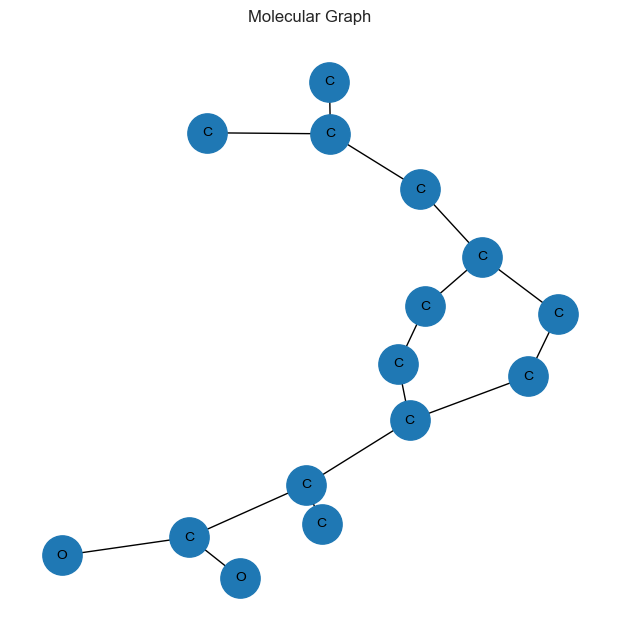

In [51]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch_geometric.utils import to_networkx

allowed_elements = ["C", "O", "N", "H", "S", "Cl", "F"]

data = ibuprofen_graph[0]

G = to_networkx(data, to_undirected=True)

# decode one-hot node features back into atom symbols
atom_indices = torch.argmax(data.x, dim=1)

labels = {
    i: allowed_elements[idx]
    for i, idx in enumerate(atom_indices.tolist())
}

plt.figure(figsize=(6, 6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=800,
    font_size=10
)

plt.title("Molecular Graph")
plt.show()

# Graph Neural Networks
----
To learn a useful representation from the input graphs, graph neural networks need to send messages along the graph edges to repeatedly exchange information between nodes. This allows the graph representation to focus on local features that are important. One of the most common ways to send these messages is to use *graph convolution*, which is similar to the convolution mechanism used for [image recognition](https://www.ibm.com/think/topics/convolutional-neural-networks). In a graph convolutional neural network, messages are passed between nodes using pytorch_geometrics's GCNConv layer.

Each convolutional layer requires both the atom matrix and connectivity matrix for our molecular graph. After each convolutional layer, our representation has a feature vector for each node in th egraph. To transform this into a single prediction at the molecule level, we must apply $global mean pooling$, which combines the node features by taking their mean.  

The neural network below already has the required layers. The forward pass has initiated the variables `x, edge_index and batch.` Using these variable and layers, define the forward pass that:
1. Passes the inputs into the first convolutional layer `x = self.conv1(x, edge_index)`
2. Applies the ReLU activation layer
3. Passes the resultant node features through the second convolutional layer `x = self.conv2(x, edge_index)`
4. Applies the ReLU activation layer
5. Applies the global mean pooling `x = global_mean_pool(x, batch)`
6. Passes the resultant representation through the linear layer to generate the prediction `x = self.layers(x)`



In [ ]:
from torch_geometric.nn import GCNConv, global_mean_pool

class SimpleGCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = GCNConv(7, 32)
        self.conv2 = GCNConv(32, 32)
        
        self.relu = nn.ReLU()
        
        self.linear = nn.Linear(32, 1)
        
    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch
        
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.conv2(x, edge_index)
        x = self.relu(x)
        x = global_mean_pool(x, batch)
        x = self.linear(x)
        return x
        ... # your code here

Now we are ready to train our graph neural network using the AqSolDB dataset. Write a script below that:
1. Generates molecular graphs 
2. Trains the graph convolutional neural network for 100 epochs using MSE loss
3. 

In [ ]:
from tdc.single_pred.adme import ADME
from torch_geometric.data import Data
import pandas as pd

from rdkit import Chem

# load the dataset 
solubility_data = ADME('Solubility_AqSolDB')
solubility_split = solubility_data.get_split() # use predefined splits 

train_df = pd.concat([solubility_split["train"], solubility_split["valid"] ])
test_df = solubility_split["test"]

# convert dataframes to np arrays 
train_smiles = train_df["Drug"].to_numpy()
train_solubility = train_df["Y"].to_numpy()

test_smiles = test_df["Drug"].to_numpy()
test_solubility = test_df["Y"].to_numpy()

 